# **End-to-End NLP Sentiment Analysis**

### Comparing TF-IDF, GloVe Embeddings, and Transformer Models

**Author:** Warda Anees

---

## Project Overview

This project develops an end-to-end Natural Language Processing (NLP) pipeline for binary sentiment classification of movie reviews.

The project investigates how different text representation techniques affect classification performance by comparing three approaches:

1. **TF-IDF + Logistic Regression** — a traditional NLP and machine learning approach
2. **GloVe Embeddings + Logistic Regression** — a semantic word representation approach
3. **Transformer-based Model** — a modern pre-trained NLP approach

The pipeline covers dataset exploration, text preprocessing, feature engineering, model training, evaluation, and comparison of the different approaches.

### Research Question

> **How does the choice of text representation affect the performance of sentiment classification models?**

### Technologies

Python • Pandas • NumPy • NLTK • Scikit-learn • GloVe • Hugging Face Transformers


In [56]:
!pip -q install -U datasets

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

In [58]:
from datasets import load_dataset
dataset = load_dataset("stanfordnlp/imdb")

In [59]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (25000, 2)
Testing set shape: (25000, 2)


In [60]:
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


## Dataset Exploration

Before preprocessing the reviews, we first examine the structure and distribution of the dataset. This helps us understand the number of samples, available features, class labels, and whether the sentiment classes are reasonably balanced.


In [61]:
print("Unique labels:", train_df["label"].unique())
print("\nClass distribution:")
print(train_df["label"].value_counts())

Unique labels: [0 1]

Class distribution:
label
0    12500
1    12500
Name: count, dtype: int64


In [62]:
train_df["sentiment"] = train_df["label"].map({
    0: "Negative",
    1: "Positive"})

test_df["sentiment"] = test_df["label"].map({
    0: "Negative",
    1: "Positive"})

In [63]:
train_df[["text", "label", "sentiment"]].head()

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,Negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,Negative
2,If only to avoid making this type of film in t...,0,Negative
3,This film was probably inspired by Godard's Ma...,0,Negative
4,"Oh, brother...after hearing about this ridicul...",0,Negative


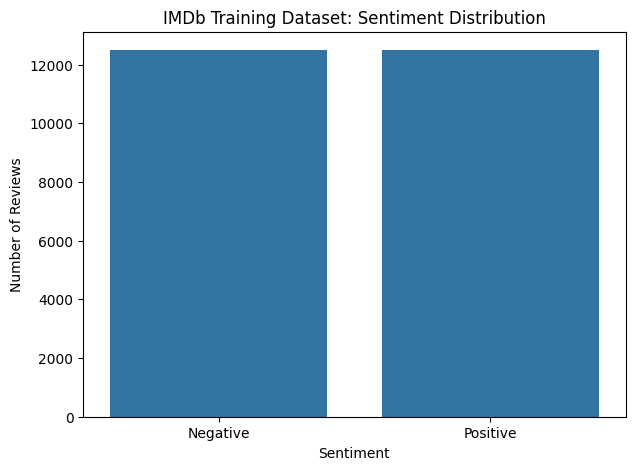

In [64]:
plt.figure(figsize=(7, 5))
sns.countplot(data=train_df,x="sentiment")

plt.title("IMDb Training Dataset: Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [65]:
print("NEGATIVE REVIEW")
print(train_df[train_df["label"] == 0]["text"].iloc[0])

print("\n")

print("POSITIVE REVIEW")
print(train_df[train_df["label"] == 1]["text"].iloc[0])

NEGATIVE REVIEW
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and 

In [66]:
print("Missing values:")
print(train_df[["text", "label"]].isnull().sum())

Missing values:
text     0
label    0
dtype: int64


#Text Data Preprocessing

Raw movie reviews contain various forms of noise, including HTML tags, punctuation, URLs, inconsistent capitalization, and common words that may provide limited information for sentiment classification.

In this stage, the text is standardized using the following preprocessing steps:

1. Convert text to lowercase
2. Remove HTML tags
3. Remove URLs
4. Remove punctuation and unnecessary symbols
5. Tokenize the text
6. Remove stop words
7. Apply lemmatization

The processed text will then be used for feature extraction and classification.


In [67]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [68]:
import re
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [69]:
stop_words = set(stopwords.words("english"))
negation_words = {"no", "not", "nor", "never"} # keeping important negation words for sentiment analysis
stop_words = stop_words - negation_words
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()  # converting text to lowercase
    text = re.sub(r"<.*?>", " ", text)  # removing HTML tags
    text = re.sub(r"http\S+|www\S+", " ", text)  # removing URLs
    text = text.translate(str.maketrans("", "", string.punctuation)) # removing punctuation
    tokens = word_tokenize(text) # tokenize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and word.isalpha()]  # removing stop words and lemmatize

    return " ".join(tokens) # joins tokens back into text

In [70]:
sample_review = train_df["text"].iloc[0]

print("BEFORE PREPROCESSING:\n")
print(sample_review)

print("\n")

print("AFTER PREPROCESSING:\n")
print(preprocess_text(sample_review))

BEFORE PREPROCESSING:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are f

In [71]:
examples = train_df["text"].iloc[:5]

comparison_df = pd.DataFrame({
    "Original Text": examples,
    "Preprocessed Text": examples.apply(preprocess_text)})
comparison_df # some few examples of the preprocessed text

,Original Text,Preprocessed Text
0,I rented I AM CURIOUS-YELLOW from my video sto...,rented curiousyellow video store controversy s...
1,"""I Am Curious: Yellow"" is a risible and preten...",curious yellow risible pretentious steaming pi...
2,If only to avoid making this type of film in t...,avoid making type film future film interesting...
3,This film was probably inspired by Godard's Ma...,film probably inspired godard masculin féminin...
4,"Oh, brother...after hearing about this ridicul...",oh brotherafter hearing ridiculous film umptee...


In [72]:
train_df["processed_text"] = train_df["text"].apply(preprocess_text)
test_df["processed_text"] = test_df["text"].apply(preprocess_text) # applying it on the entire dataset

In [73]:
train_df[["text", "processed_text", "label"]].head()

,text,processed_text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,rented curiousyellow video store controversy s...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",curious yellow risible pretentious steaming pi...,0
2,If only to avoid making this type of film in t...,avoid making type film future film interesting...,0
3,This film was probably inspired by Godard's Ma...,film probably inspired godard masculin féminin...,0
4,"Oh, brother...after hearing about this ridicul...",oh brotherafter hearing ridiculous film umptee...,0


#TF-IDF Feature Engineering

Machine learning algorithms cannot directly process raw text. Therefore, the preprocessed reviews must be converted into numerical representations.

In this project, **Term Frequency–Inverse Document Frequency (TF-IDF)** is used as the traditional NLP feature representation.

TF-IDF assigns higher weights to words that are important within a document but less common across the overall collection of documents. This allows the classifier to focus on informative terms while reducing the influence of very common words.

The TF-IDF representation will be used as input to the Logistic Regression classifier.


In [74]:
X_train = train_df["processed_text"]
y_train = train_df["label"]

X_test = test_df["processed_text"]
y_test = test_df["label"]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


In [75]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

In [76]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [77]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (25000, 10000)
Testing TF-IDF shape: (25000, 10000)


In [78]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFirst 30 features:", feature_names[:30])

Number of features: 10000

First 30 features: ['aaron' 'abandon' 'abandoned' 'abc' 'ability' 'able' 'able get'
 'able see' 'abomination' 'abortion' 'abound' 'abraham' 'abrupt'
 'abruptly' 'absence' 'absent' 'absolute' 'absolutely' 'absolutely loved'
 'absolutely no' 'absolutely nothing' 'absorbing' 'absurd' 'absurdity'
 'abuse' 'abused' 'abusive' 'abysmal' 'academy' 'academy award']


#Classification Model: Logistic Regression

Logistic Regression is used as the first classification model because it is a strong and computationally efficient baseline for text classification.

The model receives the TF-IDF vectors as input and learns the relationship between words or phrases and the sentiment labels.

The model is trained using the training set and evaluated on the previously unseen test set.


In [79]:
logistic_model = LogisticRegression(max_iter=1000) # Initializing Logistic Regression

logistic_model.fit(X_train_tfidf, y_train) # Training the model

LogisticRegression(max_iter=1000)

In [80]:
y_pred = logistic_model.predict(X_test_tfidf) # predict sentiment on the test set

In [81]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("TF-IDF + Logistic Regression Results")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

TF-IDF + Logistic Regression Results
Accuracy : 0.8871
Precision: 0.8851
Recall   : 0.8898
F1-Score : 0.8874


In [82]:
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.89      0.88      0.89     12500
    Positive       0.89      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



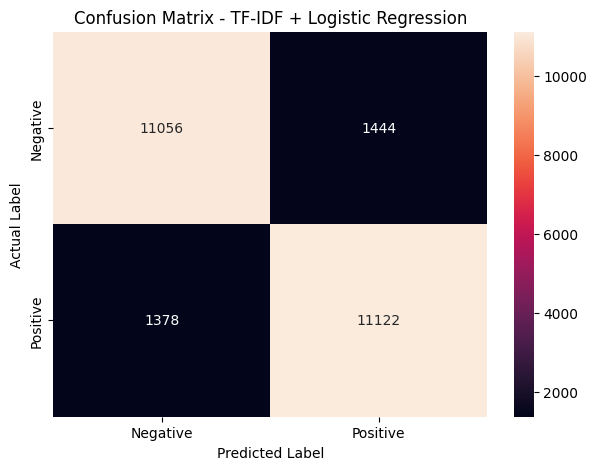

In [83]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))

sns.heatmap(cm,annot=True,fmt="d",xticklabels=["Negative", "Positive"],yticklabels=["Negative", "Positive"])

plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [84]:
results = []
results.append({
    "Model": "TF-IDF + Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1})

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + Logistic Regression,0.88712,0.885087,0.88976,0.887417


#Pre-trained Word Embeddings: GloVe

TF-IDF represents words based primarily on their importance within the dataset. However, it does not explicitly capture semantic relationships between words.

To explore a more semantic representation, this project uses **GloVe (Global Vectors for Word Representation)**, a pre-trained word embedding model.

Each word is represented as a dense numerical vector learned from a large text corpus. To obtain a representation for an entire review, the vectors of the words present in the review are averaged.

The resulting document-level embeddings are then used as input to a Logistic Regression classifier.


In [85]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

replace glove.6B.50d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace glove.6B.100d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace glove.6B.200d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace glove.6B.300d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [86]:
embedding_dim = 100
embeddings_index = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print("Number of words in GloVe:", len(embeddings_index))
print("Embedding dimension:", embedding_dim)

Number of words in GloVe: 400000
Embedding dimension: 100


In [87]:
print("Vector for 'movie':")
print(embeddings_index["movie"])

Vector for 'movie':
[ 0.38251    0.14821    0.60601   -0.51533    0.43992    0.061053
 -0.62716   -0.025385   0.1643    -0.22101    0.14423   -0.37213
 -0.21683   -0.08895    0.097904   0.6561     0.64455    0.47698
  0.83849    1.6486     0.88922   -0.1181    -0.012465  -0.52082
  0.77854    0.48723   -0.014991  -0.14127   -0.34747   -0.29595
  0.1028     0.57191   -0.045594   0.026443   0.53816    0.32257
  0.40788   -0.043599  -0.146     -0.48346    0.32036    0.55086
 -0.76259    0.43269    0.61753   -0.36503   -0.60599   -0.79615
  0.3929    -0.23668   -0.34719   -0.61201    0.54747    0.94812
  0.20941   -2.7771    -0.6022     0.8495     1.2549     0.017893
 -0.041901   2.1147    -0.026618  -0.28104    0.68124   -0.14165
  0.99249    0.49879   -0.67538    0.6417     0.42303   -0.27913
  0.063403   0.68909   -0.36183    0.053709  -0.16806    0.19422
 -0.47073   -0.14803   -0.58986   -0.2797     0.16792    0.10568
 -1.7601     0.0088254 -0.83326   -0.5836    -0.37079   -0.56591
  0

In [88]:
print("Vector shape:", embeddings_index["movie"].shape)

Vector shape: (100,)


In [89]:
def review_to_embedding(text):
    words = text.split()

    vectors = [
        embeddings_index[word]
        for word in words
        if word in embeddings_index]

    if len(vectors) == 0:
        return np.zeros(embedding_dim)

    return np.mean(vectors, axis=0)

In [90]:
sample_embedding = review_to_embedding(train_df["processed_text"].iloc[0])
print("Embedding shape:", sample_embedding.shape)

Embedding shape: (100,)


In [91]:
X_train_glove = np.vstack(X_train.apply(review_to_embedding))
X_test_glove = np.vstack(X_test.apply(review_to_embedding))

In [92]:
print("Training GloVe shape:", X_train_glove.shape)
print("Testing GloVe shape:", X_test_glove.shape)

Training GloVe shape: (25000, 100)
Testing GloVe shape: (25000, 100)


###Classification Using GloVe Features

The 100-dimensional GloVe representations are used as input to a Logistic Regression classifier. Using the same classifier as the TF-IDF experiment allows the comparison to focus primarily on the effect of the text representation rather than differences between classification algorithms.


In [93]:
glove_model = LogisticRegression(max_iter=1000)
glove_model.fit(X_train_glove, y_train)

LogisticRegression(max_iter=1000)

In [94]:
y_pred_glove = glove_model.predict(X_test_glove)

In [95]:
glove_accuracy = accuracy_score(y_test, y_pred_glove)
glove_precision = precision_score(y_test, y_pred_glove)
glove_recall = recall_score(y_test, y_pred_glove)
glove_f1 = f1_score(y_test, y_pred_glove)

print("GloVe + Logistic Regression Results")
print(f"Accuracy : {glove_accuracy:.4f}")
print(f"Precision: {glove_precision:.4f}")
print(f"Recall   : {glove_recall:.4f}")
print(f"F1-Score : {glove_f1:.4f}")

GloVe + Logistic Regression Results
Accuracy : 0.7990
Precision: 0.8025
Recall   : 0.7930
F1-Score : 0.7978


In [96]:
print(classification_report(y_test,y_pred_glove,target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.80      0.80      0.80     12500
    Positive       0.80      0.79      0.80     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000



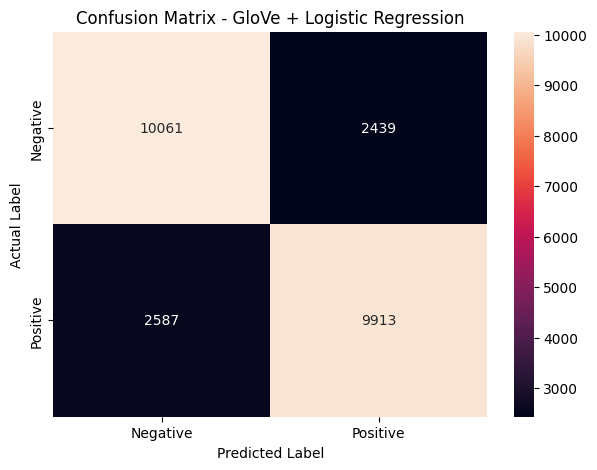

In [97]:
cm_glove = confusion_matrix(y_test, y_pred_glove)
plt.figure(figsize=(7, 5))

sns.heatmap(cm_glove,annot=True,fmt="d",xticklabels=["Negative", "Positive"],yticklabels=["Negative", "Positive"])

plt.title("Confusion Matrix - GloVe + Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [98]:
results.append({
    "Model": "GloVe + Logistic Regression",
    "Accuracy": glove_accuracy,
    "Precision": glove_precision,
    "Recall": glove_recall,
    "F1-Score": glove_f1})

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + Logistic Regression,0.88712,0.885087,0.88976,0.887417
1,GloVe + Logistic Regression,0.79896,0.802542,0.79304,0.797763


#Open-Source Pre-trained NLP Model

Traditional TF-IDF features and pre-trained word embeddings represent text using fixed numerical features. Transformer models provide a more contextual representation by considering the surrounding words when processing a sentence.

In this project, **DistilBERT**, a lightweight transformer model available through Hugging Face, is used for sentiment classification.

The selected model has already been fine-tuned for sentiment classification on the SST-2 dataset. It is therefore used as a pre-trained transfer-learning model to predict sentiment on the IMDb test reviews.

This approach demonstrates how a pre-trained transformer can be applied to a new text classification dataset without training a language model from scratch.


In [99]:
!pip -q install -U transformers

In [100]:
from transformers import pipeline
import torch

In [101]:
device = 0 if torch.cuda.is_available() else -1
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [102]:
sample_reviews = [
    "This movie was absolutely fantastic and I really enjoyed it.",
    "The movie was boring, poorly written, and disappointing."]

predictions = sentiment_pipeline(sample_reviews)

for review, prediction in zip(sample_reviews, predictions):
    print("Review:", review)
    print("Prediction:", prediction)
    print("\n")

Review: This movie was absolutely fantastic and I really enjoyed it.
Prediction: {'label': 'POSITIVE', 'score': 0.9998835325241089}


Review: The movie was boring, poorly written, and disappointing.
Prediction: {'label': 'NEGATIVE', 'score': 0.9998013377189636}




In [103]:
sample_reviews = test_df["text"].iloc[:5].tolist()
transformer_predictions = sentiment_pipeline(sample_reviews)

for i, (review, prediction) in enumerate(
    zip(sample_reviews, transformer_predictions)
):
    print(f"Review {i+1}")
    print("Actual:", "Positive" if test_df["label"].iloc[i] == 1 else "Negative")
    print("Predicted:", prediction["label"])
    print("Confidence:", round(prediction["score"], 4))
    print("\n")

Review 1
Actual: Negative
Predicted: NEGATIVE
Confidence: 0.9996


Review 2
Actual: Negative
Predicted: NEGATIVE
Confidence: 0.6171


Review 3
Actual: Negative
Predicted: NEGATIVE
Confidence: 0.9997


Review 4
Actual: Negative
Predicted: NEGATIVE
Confidence: 0.9958


Review 5
Actual: Negative
Predicted: POSITIVE
Confidence: 0.9963




In [104]:
transformer_texts = test_df["text"].tolist()
transformer_labels = test_df["label"].values

transformer_outputs = sentiment_pipeline(transformer_texts,batch_size=32,truncation=True)

In [105]:
y_pred_transformer = np.array([
    1 if output["label"] == "POSITIVE" else 0
    for output in transformer_outputs])

In [106]:
transformer_accuracy = accuracy_score(transformer_labels,y_pred_transformer)
transformer_precision = precision_score(transformer_labels,y_pred_transformer)
transformer_recall = recall_score(transformer_labels,y_pred_transformer)
transformer_f1 = f1_score(transformer_labels,y_pred_transformer)

print("DistilBERT Results")
print(f"Accuracy : {transformer_accuracy:.4f}")
print(f"Precision: {transformer_precision:.4f}")
print(f"Recall   : {transformer_recall:.4f}")
print(f"F1-Score : {transformer_f1:.4f}")

DistilBERT Results
Accuracy : 0.8907
Precision: 0.9146
Recall   : 0.8619
F1-Score : 0.8875


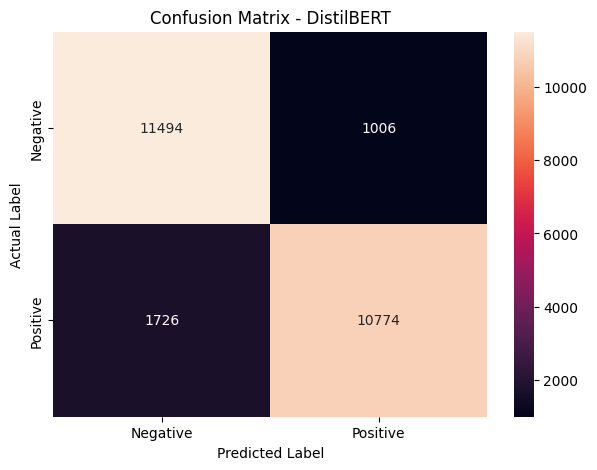

In [107]:
plt.figure(figsize=(7, 5))
cm_transformer = confusion_matrix(transformer_labels,y_pred_transformer)
sns.heatmap(cm_transformer,annot=True,fmt="d",xticklabels=["Negative", "Positive"],yticklabels=["Negative", "Positive"])

plt.title("Confusion Matrix - DistilBERT")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

#Final Model Comparison

Three different NLP approaches were evaluated for binary sentiment classification on the IMDb movie review dataset.

1. **TF-IDF + Logistic Regression** — a traditional sparse text representation combined with a linear classifier.
2. **GloVe + Logistic Regression** — dense pre-trained word embeddings combined with the same classifier.
3. **DistilBERT** — a transformer-based pre-trained sentiment classification model.

The models are compared using accuracy, precision, recall, and F1-score.


In [108]:
results.append({
    "Model": "DistilBERT",
    "Accuracy": transformer_accuracy,
    "Precision": transformer_precision,
    "Recall": transformer_recall,
    "F1-Score": transformer_f1})

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + Logistic Regression,0.88712,0.885087,0.88976,0.887417
1,GloVe + Logistic Regression,0.79896,0.802542,0.79304,0.797763
2,DistilBERT,0.89072,0.914601,0.86192,0.887479


In [109]:
results_display = results_df.copy()
for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_display[column] = (results_display[column] * 100).round(2).astype(str) + "%"
results_display

,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + Logistic Regression,88.71%,88.51%,88.98%,88.74%
1,GloVe + Logistic Regression,79.9%,80.25%,79.3%,79.78%
2,DistilBERT,89.07%,91.46%,86.19%,88.75%


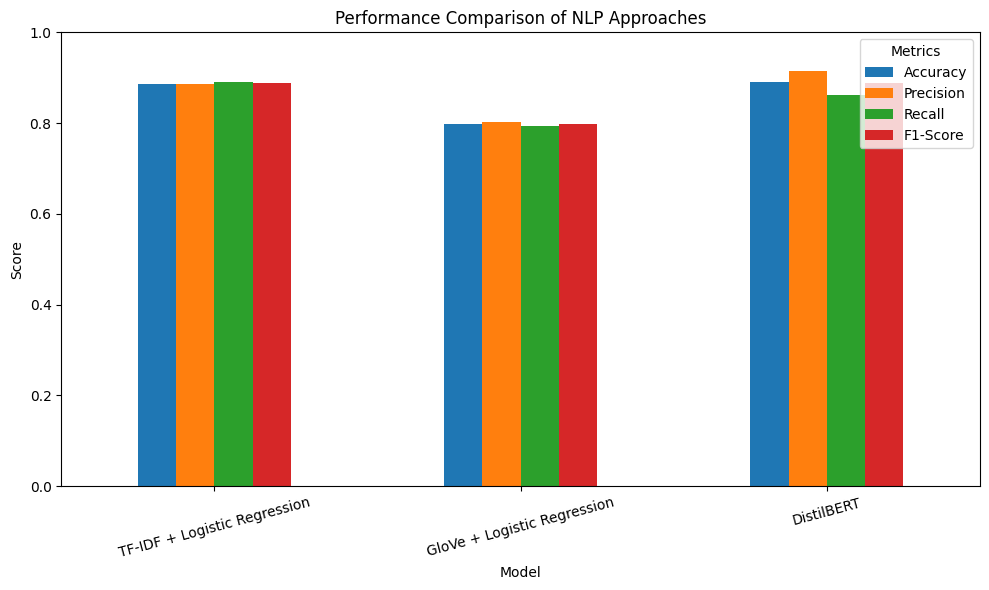

In [110]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
results_plot = results_df.set_index("Model")[metrics]

results_plot.plot(kind="bar",figsize=(10, 6))

plt.title("Performance Comparison of NLP Approaches")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

### Performance Analysis

The experimental results show that **DistilBERT achieved the highest overall accuracy at 89.07%**, slightly outperforming the TF-IDF + Logistic Regression baseline at 88.71%. DistilBERT also achieved the highest precision (91.46%) and F1-score (88.75%).

Interestingly, the traditional TF-IDF approach remained highly competitive despite its considerably simpler architecture. Its F1-score of 88.74% was almost identical to that of DistilBERT. This demonstrates that traditional feature engineering can remain highly effective for sentiment classification when informative unigram and bigram features are used.

GloVe + Logistic Regression achieved a lower accuracy of 79.90%. In this experiment, each review was represented by averaging its word embeddings into a single 100-dimensional vector. This representation captures semantic information but loses word order, phrase-level relationships, and contextual information, which can be important for sentiment analysis.

Overall, the results demonstrate the progression from sparse statistical representations (TF-IDF), to dense pre-trained word embeddings (GloVe), to contextual transformer-based representations (DistilBERT).


# Conclusion

This project developed an end-to-end NLP sentiment classification pipeline using the IMDb movie review dataset. Three different text representation approaches were investigated: TF-IDF with Logistic Regression, GloVe embeddings with Logistic Regression, and the pre-trained DistilBERT transformer model.

Among the three approaches, **DistilBERT achieved the highest accuracy (89.07%), precision (91.46%), and F1-score (88.75%)**, making it the best overall-performing approach in this experiment. Its contextual representation allows it to capture relationships between words more effectively than traditional or non-contextual representations.

However, **TF-IDF + Logistic Regression performed remarkably close to DistilBERT**, achieving an F1-score of 88.74% and the highest recall of 88.98%. This demonstrates that traditional NLP techniques can remain highly competitive while requiring substantially less computational complexity.

The GloVe-based approach achieved a lower accuracy of 79.90%. The use of mean pooling to convert each review into a single 100-dimensional vector resulted in the loss of word order and contextual information, which limited its effectiveness for sentiment classification.

Overall, the experiment demonstrates that **the choice of text representation has a significant impact on NLP classification performance**. While transformer-based models provide the strongest overall results, traditional TF-IDF features can still provide an effective and computationally efficient baseline for sentiment analysis.
